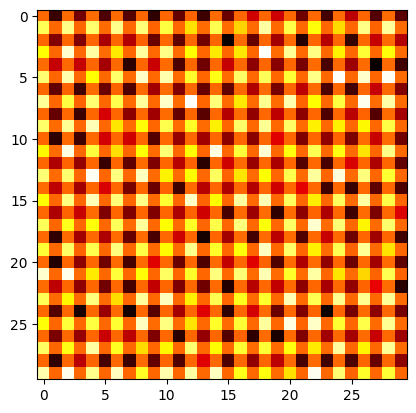

In [3]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import matplotlib.pyplot as plt
terrain = np.load("01_terrain.npy")
plt.imshow(terrain, cmap='hot', interpolation='nearest')
plt.show()


In [4]:
A = (15,15)
B = (29, 29)

In [5]:
def read_input():
    i, j = input().replace(' ', '').split(',')
    return int(i), int(j)

In [6]:
from collections import defaultdict

def manhattn(a, b):
    # STUDENTSKI KOD BEGIN
    return abs(a[0] - b[0]) + abs(a[1] - b[1])
    # STUDENTSKI KOD END

def astar(matrix, start, end, h):
    # STUDENTSKI KOD BEGIN
    rows, cols = matrix.shape
    open_set, closed_set = set([start]), set()

    cheapest_paths = defaultdict(lambda: float('inf'))
    cheapest_paths[start] = 0

    parent = {start: None}

    def get_best():
        result, result_value = None, float('inf')
        for node in open_set:
            new_value = cheapest_paths[node] + h(node, end)
            if not result or new_value < result_value:
                result, result_value = node, new_value
        return result

    path_found = False
    while len(open_set) > 0:
        current = get_best()
        if current == end:
            path_found = True
            break

        i, j = current
        for neighbour in ((i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1)):
            ni, nj = neighbour
            if not (0 <= ni < rows and 0 <= nj < cols):
                continue

            new_path_to_neighbour_weight = cheapest_paths[current] + transition_time(matrix, current, neighbour)
            if neighbour not in open_set and neighbour not in closed_set:
                open_set.add(neighbour)
                parent[neighbour] = current
                cheapest_paths[neighbour] = new_path_to_neighbour_weight
            elif new_path_to_neighbour_weight < cheapest_paths[neighbour]:
                parent[neighbour] = current
                cheapest_paths[neighbour] = new_path_to_neighbour_weight
                if neighbour in closed_set:
                    closed_set.remove(neighbour)
                    open_set.add(neighbour)

        open_set.remove(current)
        closed_set.add(current)

    if path_found:
        path = []
        while end is not None:
            path.append(end)
            end = parent[end]
        path.reverse()
        return path
    else:
        return []
    # STUDENTSKI KOD END


def transition_time(terrain, current, neighbor):
    current_height = terrain[current]
    neighbor_height = terrain[neighbor]
    difference = neighbor_height - current_height
    if difference > 0:
        return 2 * difference
    return 0.7 * (-difference)


def compute_time(terrain, path):
    # STUDENTSKI KOD BEGIN
    total = 0.0
    for current, neighbor in zip(path, path[1:]):
        total += transition_time(terrain, current, neighbor)
    return total
    # STUDENTSKI KOD END


In [7]:
path = astar(terrain, A, B, manhattn)
print(path)
time = compute_time(terrain, path)
print(time)

[(15, 15), (14, 15), (14, 16), (14, 17), (14, 18), (14, 19), (14, 20), (14, 21), (14, 22), (15, 22), (15, 23), (16, 23), (17, 23), (18, 23), (18, 24), (19, 24), (20, 24), (21, 24), (21, 25), (21, 26), (22, 26), (22, 27), (23, 27), (24, 27), (25, 27), (26, 27), (26, 28), (26, 29), (27, 29), (28, 29), (29, 29)]
2436.4839334157305
